I want to see the effects of the new lr scheduling

In [1]:
# Add project root to path so we can import from data_manipulation and model
import sys
from pathlib import Path

def _find_project_root():
    cwd = Path.cwd()
    if (cwd / "data_manipulation").is_dir():
        return cwd
    if (cwd.parent / "data_manipulation").is_dir():
        return cwd.parent
    return cwd  # fallback

project_root = _find_project_root()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from functools import partial
import numpy as np


# Imports from data_manipulation and model
from data_manipulation.data_split import create_dataloader, DemandDataset
from model.functions import pinball_loss, rmse, train, get_test_loss, pinball_loss_tensor, pinball_loss_sum, normalize_batch, compute_mean_std

In [3]:
class thread_net(nn.Module):

    @staticmethod
    def _mlp(sizes: list[int]) -> nn.Sequential:
        """Linear layers with ReLU between; no ReLU after the last linear."""
        if len(sizes) < 2:
            raise ValueError("layer_list needs at least [input_dim, output_dim]")
        layers: list[nn.Module] = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                layers.append(nn.ReLU())
        return nn.Sequential(*layers)

    def __init__(self, layer_list=[9, 80, 80, 80, 1], num_nets=500):
        super().__init__()
        self.layer_list = list(layer_list)
        self.nets = nn.ModuleList(
            [self._mlp(self.layer_list) for _ in range(num_nets)]
        )
        self.num_nets = num_nets

    def forward(self, x):
        outs = [net(x[:, i::self.num_nets]) for i, net in enumerate(self.nets)]
        return torch.cat(outs, dim=1)

In [4]:
class thread_net_multi(nn.Module):

    @staticmethod
    def _mlp(sizes: list[int]) -> nn.Sequential:
        """Linear layers with ReLU between; no ReLU after the last linear."""
        if len(sizes) < 2:
            raise ValueError("layer_list needs at least [input_dim, output_dim]")
        layers: list[nn.Module] = []
        for i in range(len(sizes) - 1):
            layers.append(nn.Linear(sizes[i], sizes[i + 1]))
            if i < len(sizes) - 2:
                layers.append(nn.ReLU())
        return nn.Sequential(*layers)

    def __init__(self, layer_list=[9, 80, 80, 80, 3], num_nets=500):
        super().__init__()
        self.layer_list = list(layer_list)
        self.nets = nn.ModuleList(
            [self._mlp(self.layer_list) for _ in range(num_nets)]
        )
        self.num_nets = num_nets
        self.training = True

    def forward(self, x):
        if self.training:
            outs = [net(x[:, i::self.num_nets]) for i, net in enumerate(self.nets)]
            return torch.cat(outs, dim=1)
        else:
            # First horizon only, all batch rows: each net -> [batch], stack -> [batch, num_nets]
            outs = [net(x[:, i::self.num_nets])[:, 0] for i, net in enumerate(self.nets)]
            return torch.stack(outs, dim=1)

In [5]:
all_specs = [
    "sales",
    "7_day_rolling_ema",	
    "30_day_rolling_ema",
    "90_day_rolling_ema",
    "30_day_rolling_min",
    "5_day_lag",
    "6_day_lag",
    "7_day_lag",
    "diff_180_day",
]

In [6]:
h_cost = 1
l_cost = 3
num_epochs = 500

num_nets = 500

# First compute the original without mutliple days

First compute with Normalization

In [7]:
# Get data for spec
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    specs=all_specs,
    combine_items=True,
    combine_stores=True
    )

In [8]:
num_in = train_loader.dataset.x.shape[1]
print(num_in / 500)

9.0


In [9]:
net_1 = thread_net(num_nets=num_nets)

loss = partial(pinball_loss_sum, h_cost=h_cost, l_cost=l_cost)
og_loss = partial(pinball_loss, h_cost=h_cost, l_cost=l_cost)
loss_tensor = partial(pinball_loss_tensor, h_cost=h_cost, l_cost=l_cost)
optimizer = torch.optim.Adam(net_1.parameters(), lr=1.5)


train_losses_1, val_losses_1 = train(net_1, optimizer, loss, train_loader, val_loader, epochs=num_epochs, eval_interval=10, device="cpu", use_one_cycle_lr=True)
test_loss_1 = get_test_loss(net_1, test_loader, og_loss, "cpu")

# Get matrix loss
test_data = test_loader.dataset.x
test_y = test_loader.dataset.y
test_y_hat = net_1(test_data)
test_loss_tensor_1 = loss_tensor(test_y_hat, test_y)

Training: 100%|██████████| 500/500 [05:42<00:00,  1.46step/s, train_loss=74916.9688]                          


# Now compute with sneaky 3 days

In [10]:
train_loader, val_loader, test_loader = create_dataloader(
    batch_size=8, 
    test_batch_size=1,
    pin_memory=False,
    specs=all_specs,
    combine_items=True,
    combine_stores=True,
    num_days=3
    )

net_2 = thread_net(num_nets=num_nets)
optimizer_2 = torch.optim.Adam(net_2.parameters(), lr=0.001)
train_losses_2, val_losses_2 = train(net_2, optimizer_2, loss, train_loader, val_loader, epochs=num_epochs, eval_interval=10, device="cpu", use_one_cycle_lr=True)

# Set model to not trraining
net_2.training = False

# Get test losses
test_loss_2 = get_test_loss(net_2, test_loader, og_loss, "cpu")

test_data = test_loader.dataset.x
test_y = test_loader.dataset.y
test_y_hat = net_2(test_data)
test_loss_tensor_2 = loss_tensor(test_y_hat, test_y)

TypeError: create_dataloader() got an unexpected keyword argument 'num_days'

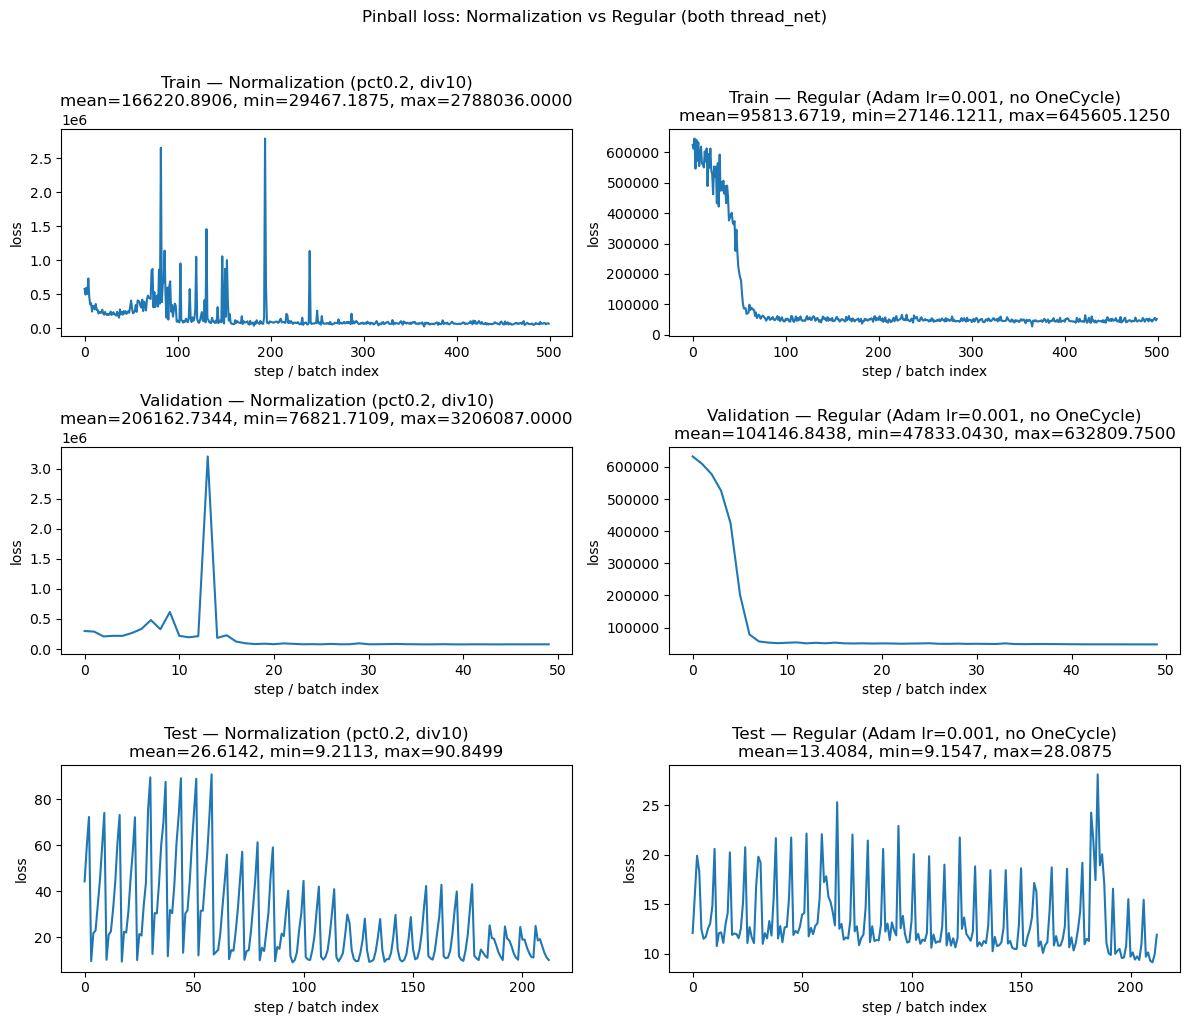

In [ ]:
def _stats(a):
    t = torch.tensor(a, dtype=torch.float32)
    return t.mean().item(), t.min().item(), t.max().item()


fig, axs = plt.subplots(3, 2, figsize=(12, 10))

m, lo, hi = _stats(train_losses_1)
axs[0, 0].plot(train_losses_1)
axs[0, 0].set_title(f"Train — OG \nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")
m, lo, hi = _stats(val_losses_1)
axs[1, 0].plot(val_losses_1)
axs[1, 0].set_title(f"Validation — OG \nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")
m, lo, hi = _stats(test_loss_1)
axs[2, 0].plot(test_loss_1)
axs[2, 0].set_title(f"Test — OG \nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")

m, lo, hi = _stats(train_losses_2)
axs[0, 1].plot(train_losses_2)
axs[0, 1].set_title(f"Train — New split\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")
m, lo, hi = _stats(val_losses_2)
axs[1, 1].plot(val_losses_2)
axs[1, 1].set_title(f"Validation — New split\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")
m, lo, hi = _stats(test_loss_2)
axs[2, 1].plot(test_loss_2)
axs[2, 1].set_title(f"Test — New split\nmean={m:.4f}, min={lo:.4f}, max={hi:.4f}")

for ax in axs.flat:
    ax.set_xlabel("step / batch index")
    ax.set_ylabel("loss")
fig.suptitle("Pinball loss: OG vs New split (both thread_net)", y=1.02)
plt.tight_layout()
plt.show()

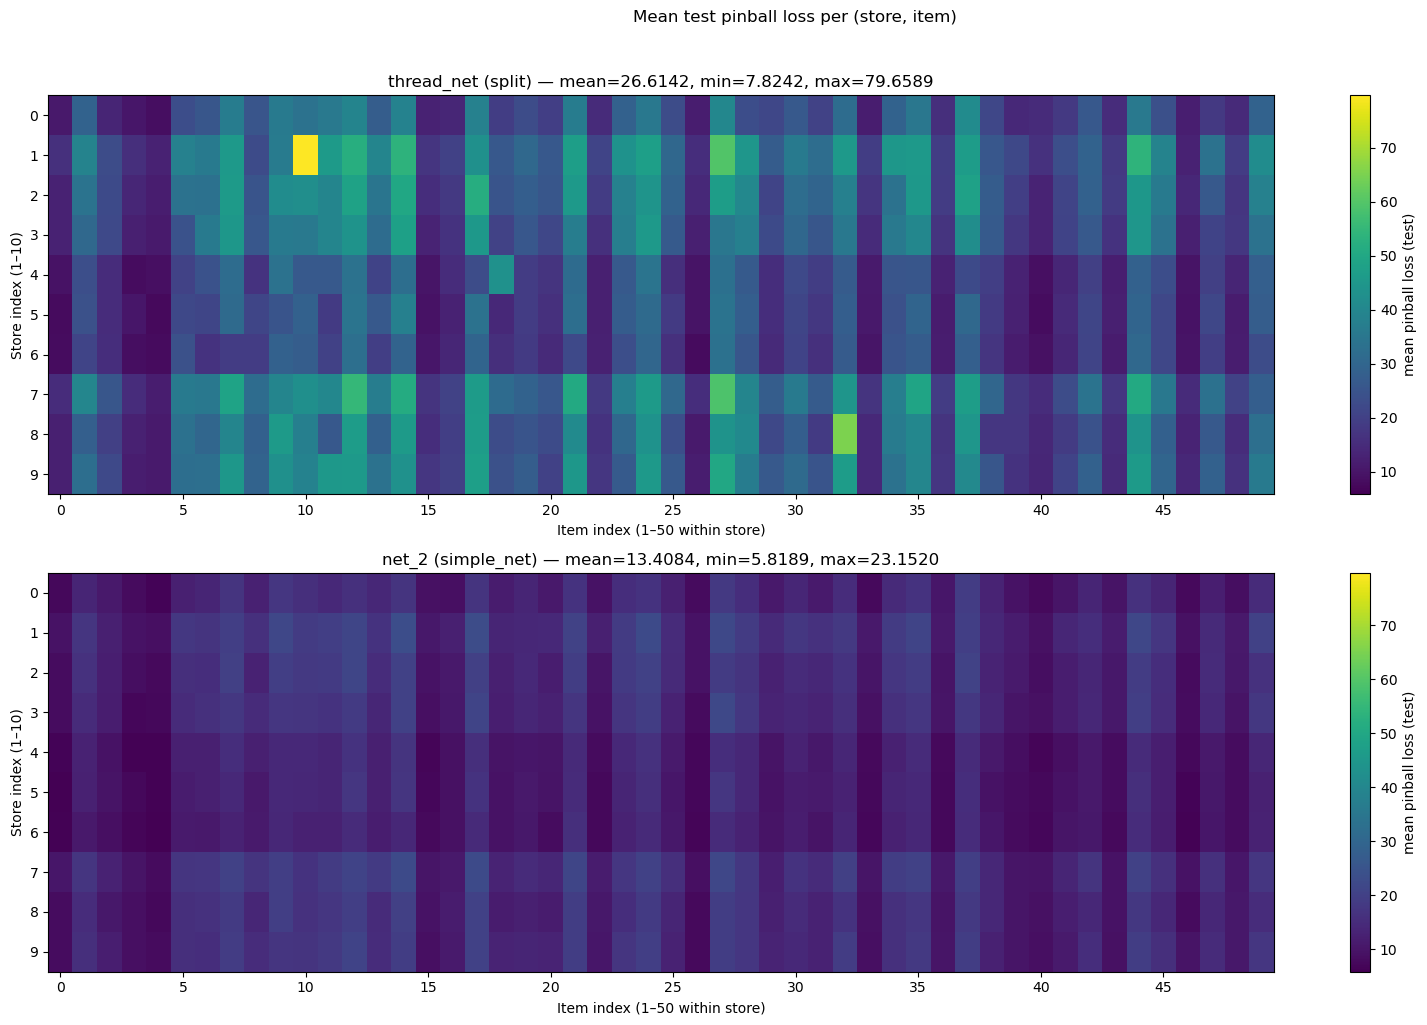

In [ ]:
loss_per_col_1 = test_loss_tensor_1.mean(dim=0).detach().cpu().numpy()
loss_per_col_2 = test_loss_tensor_2.mean(dim=0).detach().cpu().numpy()

loss_matrix = loss_per_col_1.reshape(10, 50)
loss_matrix_2 = loss_per_col_2.reshape(10, 50)

vmin = float(min(loss_matrix.min(), loss_matrix_2.min()))
vmax = float(max(loss_matrix.max(), loss_matrix_2.max()))

fig, axes = plt.subplots(2, 1, figsize=(16, 10))
for ax, M, name in (
    (axes[0], loss_matrix, "OG"),
    (axes[1], loss_matrix_2, "New split"),
):
    im = ax.imshow(M, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax)
    ax.set_xlabel("Item index (1–50 within store)")
    ax.set_ylabel("Store index (1–10)")
    ax.set_title(
        f"{name} — mean={M.mean():.4f}, min={M.min():.4f}, max={M.max():.4f}"
    )
    plt.colorbar(im, ax=ax, label="mean pinball loss (test)")
    ax.set_xticks(np.arange(0, n_items, 5))
    ax.set_yticks(np.arange(n_stores))
plt.suptitle("Mean test pinball loss per (store, item)", y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print(np.sum(loss_matrix > loss_matrix_2))
print(np.mean(loss_matrix - loss_matrix_2))
print(np.sum(loss_matrix < loss_matrix_2))


500
13.205773
0
